### Analysis of E-Commerce dataset

In [1]:
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2_contingency

In [3]:
db_path = 'data_source/processed/ecommerce.db'
table_name = 'ecommerce'

##### Read data from SQLite table

In [4]:
con = sqlite3.connect(db_path)
df = pd.read_sql_query(f"SELECT * from {table_name}", con)
con.close()

In [5]:
df.head()

,index,Customer_Id,Order_Date,Time,Aging,Gender,Device_Type,Customer_Login_type,Product_Category,Product,...,Order_Priority,Payment_method,shipping_speed_category,customer_total_sales,customer_total_profit,customer_value_segment,order_ts,cumulative_discount,dynamic_shipping_cost,profit_after_dynamic_shipping
0,0,10002,2018-08-19 22:00:00,2026-04-07 20:26:30,10.0,Male,Web,Member,Electronic,Fans,...,Critical,credit_card,delayed,149.0,66.0,medium_value,2018-08-20 20:26:30,0.1,5.6457,66.9543
1,1,10006,2018-06-13 22:00:00,2026-04-06 22:09:22,5.0,Male,Web,Member,Electronic,Samsung Mobile,...,Medium,credit_card,standard,440.0,269.0,high_value,2018-06-13 22:09:22,0.2,5.4600,138.8400
2,2,10006,2018-08-07 22:00:00,2026-04-07 05:25:41,7.0,Male,Web,Member,Electronic,Samsung Mobile,...,Medium,credit_card,delayed,440.0,269.0,high_value,2018-08-08 05:25:41,0.3,4.7100,146.8900
3,3,10013,2018-05-16 22:00:00,2026-04-07 16:30:32,8.0,Male,Web,Member,Fashion,Fossil Watch,...,Medium,credit_card,delayed,159.0,74.2,medium_value,2018-05-17 16:30:32,0.3,3.6120,77.9880
4,4,10015,2018-04-23 22:00:00,2026-04-07 20:29:43,6.0,Female,Web,Member,Fashion,Running Shoes,...,Medium,credit_card,standard,224.0,130.6,medium_value,2018-04-24 20:29:43,0.2,4.7820,138.9180


## Analysis (run `python etl.py` from project root so SQLite includes transform columns)

## 1. Time-based segmentation: category mix by shipping_speed_category

In [14]:
df.Aging.describe()

count    51289.000000
mean         5.255035
std          2.959948
min          1.000000
25%          3.000000
50%          5.000000
75%          8.000000
max         10.500000
Name: Aging, dtype: float64

In [7]:
# --- 1. Time-based segmentation: category mix by shipping_speed_category ---
assert "shipping_speed_category" in df.columns, "Re-run etl.py to refresh SQLite."
mix = (
    df.groupby(["shipping_speed_category", "Product_Category"])
    .size()
    .reset_index(name="n")
)
pivot = mix.pivot(index="Product_Category", columns="shipping_speed_category", values="n").fillna(0)
display(pivot.head(10))

shipping_speed_category,delayed,express,standard
Product_Category,,,
Auto & Accessories,2958,1482,3065
Electronic,1043,547,1111
Fashion,9093,7242,9311
Home & Furniture,6192,3011,6235


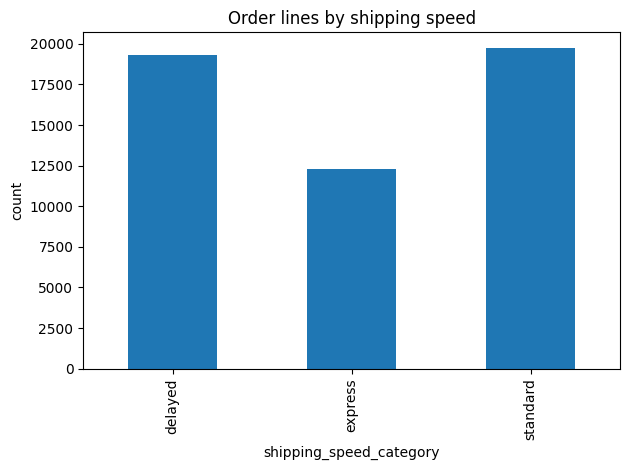

In [8]:
mix.groupby("shipping_speed_category")["n"].sum().plot.bar(title="Order lines by shipping speed")
plt.ylabel("count")
plt.tight_layout()
plt.show()

## 2. Customer value segment: category & order priority

In [12]:
# --- 2. Customer value segment: category & order priority ---
for seg in sorted(df["customer_value_segment"].dropna().unique()):
    sub = df[df["customer_value_segment"] == seg]
    print(f"\n{seg} — top categories:\n", sub["Product_Category"].value_counts().head(5))
    print(f"="*30)
    print(f"{seg} — Order_Priority %:\n", sub["Order_Priority"].value_counts(normalize=True).round(3))
    print(f"="*30)


high_value — top categories:
 Product_Category
Fashion               12454
Home & Furniture       6483
Auto & Accessories     3427
Electronic              994
Name: count, dtype: int64
high_value — Order_Priority %:
 Order_Priority
Medium      0.575
High        0.303
Critical    0.075
Low         0.047
Name: proportion, dtype: float64

low_value — top categories:
 Product_Category
Fashion               5363
Home & Furniture      4508
Auto & Accessories    2609
Electronic             711
Name: count, dtype: int64
low_value — Order_Priority %:
 Order_Priority
Medium      0.567
High        0.306
Critical    0.083
Low         0.044
Name: proportion, dtype: float64

medium_value — top categories:
 Product_Category
Fashion               7829
Home & Furniture      4447
Auto & Accessories    1469
Electronic             996
Name: count, dtype: int64
medium_value — Order_Priority %:
 Order_Priority
Medium      0.578
High        0.298
Critical    0.074
Low         0.050
Name: proportion, dtype: 

## 3. Cumulative discount vs simple loyalty proxies

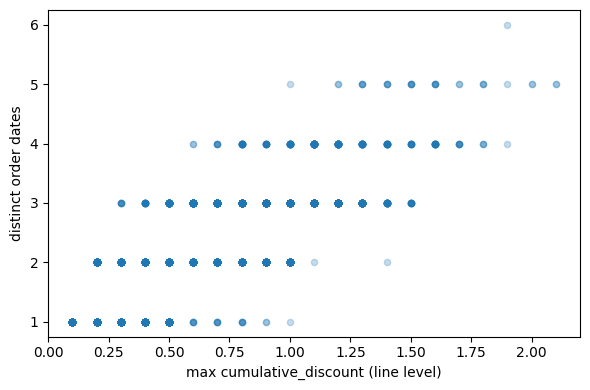

In [15]:
# --- 3. Cumulative discount vs simple loyalty proxies ---
df["_od"] = pd.to_datetime(df["Order_Date"])
cust = (
    df.groupby("Customer_Id", as_index=False)
    .agg(orders=("_od", "nunique"), max_cum_disc=("cumulative_discount", "max"), aov=("Sales", "mean"))
)
cust.plot.scatter(x="max_cum_disc", y="orders", alpha=0.25, figsize=(6, 4))
plt.xlabel("max cumulative_discount (line level)")
plt.ylabel("distinct order dates")
plt.tight_layout()
plt.show()

## 4. Dynamic shipping vs recorded

In [16]:
# --- 4. Dynamic shipping vs recorded ---
print("Sum Profit (recorded):", round(df["Profit"].sum(), 2))
print("Sum profit_after_dynamic_shipping:", round(df["profit_after_dynamic_shipping"].sum(), 2))

Sum Profit (recorded): 3611186.6
Sum profit_after_dynamic_shipping: 3716874.86


## 5. Gender: top 3 categories + chi-square (top categories only)

In [ ]:
# --- 5. Gender: top 3 categories + chi-square (top categories only) ---
top_cats = df["Product_Category"].value_counts().nlargest(15).index
sub = df[df["Product_Category"].isin(top_cats)]
ct = pd.crosstab(sub["Gender"], sub["Product_Category"])
chi2, p, dof, _ = chi2_contingency(ct)
print(f"Chi-square (Gender x top-15 categories): chi2={chi2:.2f}, p={p:.4e}, dof={dof}")

for g in sorted(sub["Gender"].dropna().unique()):
    print(f"\nTop 3 categories ({g}):\n", sub.loc[sub["Gender"] == g, "Product_Category"].value_counts().head(3))
    print(f"="*30)

Chi-square (Gender x top-15 categories): chi2=989.37, p=3.6319e-214, dof=3

Top 3 categories (Female):
 Product_Category
Fashion               11365
Home & Furniture       7980
Auto & Accessories     2323
Name: count, dtype: int64

Top 3 categories (Male):
 Product_Category
Fashion               14281
Home & Furniture       7458
Auto & Accessories     5182
Name: count, dtype: int64


**Key Takeaways**  
- **Segments:** Prioritize fulfillment for `high_value` (e.g. priority shipping on their top categories); test promotions on `low_value` high-frequency SKUs.

- **Discount vs loyalty:** Treat correlation as associative only; use controlled experiments for causal claims.  

- **Dynamic shipping:** If `profit_after_dynamic_shipping` drops sharply, revisit priority/category weights.  

- **Gender × category:** If the chi-square p-value is small, preferences differ significantly across genders. Therefore, tailor creatives and bundles to top categories per gender; if not significant, avoid over-segmenting by gender alone.